# Ferry Capacity Utilization & Operational Efficiency Analytics System

#### Ferries operating from Jack Layton Ferry Terminal provide year-round transportation to Centre Island, Hanlan’s Point, and Ward’s Island. Ferry operations involve fixed vessel capacity, staffing constraints, and seasonal demand fluctuations.

### Problem Statement
#### Despite the availability of detailed ticket sales and redemption data, ferry operations lack a structured analytical framework to:

  ### Measure capacity utilization patterns
  
 ##### > Identify over-utilization and under-utilization windows
#####  > Quantify operational inefficiencies during off-peak periods
#####  > Support evidence-based resource allocation decisions

### Primary Objectives
##### > Quantify ferry capacity utilization using ticket activity data
##### > Identify inefficiencies in ferry deployment across time intervals
##### > Detect congestion-prone and idle-capacity periods

### Secondary Objectives
##### > Support operational cost optimization
##### > Improve passenger comfort and safety
##### > Enable strategic planning for seasonal operations

### Dataset Description
#### Column	Description
#####  > _id         	     ----        Unique row identifier
#####  > Timestamp	         ----        15-minute interval end time
#####  > Sales Count	     ----        Tickets sold in interval
#####  > Redemption Count	 ----        Tickets redeemed in interval

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load data 
df = pd.read_csv("C:/Users/nehau/Downloads/Toronto Island Ferry Tickets.csv")

In [3]:
#Read data 
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [4]:
# Get the dimensions of the data frame
df.shape

(261538, 4)

In [5]:
# Get the row names of the dataframe
df.index

RangeIndex(start=0, stop=261538, step=1)

In [6]:
# Get the column names of the data frame
df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count'], dtype='object')

In [7]:
# Get the basic information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [8]:
df.isnull().sum()

_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [9]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [10]:
# remove duplicates

df = df.drop_duplicates()

In [11]:
df = df.dropna()

In [12]:
#Convert timestamps to datetime objects

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp")

In [13]:
#Sort data
df = df.sort_values("Timestamp")

In [14]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261538 entries, 2015-05-01 13:30:00 to 2025-12-21 22:30:00
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   _id               261538 non-null  int64
 1   Redemption Count  261538 non-null  int64
 2   Sales Count       261538 non-null  int64
dtypes: int64(3)
memory usage: 8.0 MB


,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01 13:30:00,261538,0,1
2015-05-01 15:15:00,261537,0,2
2015-05-01 15:45:00,261536,0,1
2015-05-01 16:00:00,261535,1,0
2015-05-04 16:00:00,261534,0,2


### Data Ingestion & Structuring
 ##### >Load historical ticket data (2015–2025)
 ##### >Convert timestamps to datetime objects
 ##### >Aggregate data to multiple resolutions:
##### .15-minute,
##### .Hourly,
##### .Daily

In [15]:
# 15min aggregation

df_15min = df.resample("15min").sum()
df_15min.head()

,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01 13:30:00,261538,0,1
2015-05-01 13:45:00,0,0,0
2015-05-01 14:00:00,0,0,0
2015-05-01 14:15:00,0,0,0
2015-05-01 14:30:00,0,0,0


In [16]:
#Hourly aggregation
df_hourly = df.resample("h").sum()
df_hourly.head()

,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01 13:00:00,261538,0,1
2015-05-01 14:00:00,0,0,0
2015-05-01 15:00:00,523073,0,3
2015-05-01 16:00:00,261535,1,0
2015-05-01 17:00:00,0,0,0


In [17]:
#Daily aggregation
df_daily = df.resample("D").sum()
df_daily.head()

,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01,1046146,1,4
2015-05-02,0,0,0
2015-05-03,0,0,0
2015-05-04,4968975,12,75
2015-05-05,12028655,537,549


In [18]:
#Check dataset shape
print("Original:",df.shape)
print("15min:",df_15min.shape)
print("hourly:",df_hourly.shape)
print("daily:",df_daily.shape)

Original: (261538, 3)
15min: (373189, 3)
hourly: (93298, 3)
daily: (3888, 3)


#### Data Quality & Consistency Checks
##### >Identify missing or irregular intervals
##### >Validate negative or zero-count anomalies
##### >Smooth extreme spikes using rolling statistics

In [19]:
# check time differences
time_diff = df.index.to_series().diff().value_counts()
print(time_diff)

Timestamp
0 days 00:15:00    236262
0 days 00:30:00     13415
0 days 00:45:00      4407
0 days 01:00:00      1834
0 days 01:15:00       782
0 days 01:30:00       526
0 days 07:00:00       469
0 days 01:45:00       363
0 days 02:00:00       304
0 days 02:15:00       253
0 days 02:30:00       225
0 days 06:45:00       199
0 days 02:45:00       193
0 days 03:00:00       165
0 days 07:30:00       163
0 days 07:15:00       159
0 days 03:30:00       140
0 days 03:45:00       128
0 days 03:15:00       124
0 days 06:00:00       114
0 days 04:30:00       113
0 days 04:00:00       105
0 days 06:30:00       102
0 days 05:00:00        97
0 days 04:15:00        97
0 days 05:30:00        96
0 days 06:15:00        96
0 days 04:45:00        93
0 days 05:15:00        85
0 days 05:45:00        85
0 days 08:00:00        77
0 days 07:45:00        62
0 days 08:15:00        57
0 days 08:30:00        51
0 days 08:45:00        21
0 days 09:15:00        17
0 days 09:00:00        15
0 days 09:30:00        12
0 

In [20]:
# Identify the missing or irregular intervals

full_range = pd.date_range(start = df.index.min(), end = df.index.max(),freq = "15min")
missing_timestamps = full_range.difference(df.index)
print("Total missing intervals:",len(missing_timestamps))


Total missing intervals: 111651


In [21]:
df = df.reindex(full_range)
df["Sales Count"] = df["Sales Count"].fillna(0)
df["Redemption Count"] = df["Redemption Count"].fillna(0)

In [22]:
# Remove negative or invalid values
negatives = df[(df["Sales Count"]<0) | (df["Redemption Count"]<0)]
print(negatives)

Empty DataFrame
Columns: [_id, Redemption Count, Sales Count]
Index: []


In [23]:

zero_activity = df[(df["Sales Count"] == 0) & (df["Redemption Count"]==0)]
print("Zero activity intervals:",zero_activity.shape[0])

Zero activity intervals: 111651


In [24]:
# Rolling mean

df["Sales_Smoothed"] = df["Sales Count"].rolling(window=15,min_periods=1).mean()
df["Redemption_Smoothed"] = df["Redemption Count"].rolling(window=15,min_periods=1).mean()

In [25]:
# Rolling medium 
df["Sales_Median"] = df["Sales Count"].rolling(window=15,min_periods=1).median()
df["Redemption_Median"] = df["Redemption Count"].rolling(window=15,min_periods=1).median()

In [26]:
# Detect extreme spikes
Q1 = df["Sales Count"].quantile(0.25)
Q3 = df["Sales Count"].quantile(0.75)
IQR = Q3 -Q1
spikes = df[df["Sales Count"] > Q3+1.5*IQR]

print(spikes.head())

                          _id  Redemption Count  Sales Count  Sales_Smoothed  \
2015-05-05 13:45:00  261488.0               0.0         86.0       24.400000   
2015-05-06 14:15:00  261442.0              13.0         66.0       33.933333   
2015-05-06 14:30:00  261441.0               0.0         69.0       35.533333   
2015-05-06 15:15:00  261438.0               0.0         79.0       39.866667   
2015-05-07 10:45:00  261398.0               6.0        107.0       16.866667   

                     Redemption_Smoothed  Sales_Median  Redemption_Median  
2015-05-05 13:45:00            23.266667          18.0                2.0  
2015-05-06 14:15:00            25.333333          30.0               13.0  
2015-05-06 14:30:00            23.466667          30.0                5.0  
2015-05-06 15:15:00            23.266667          30.0                5.0  
2015-05-07 10:45:00             1.600000           6.0                0.0  


##### Capacity Utilization Feature Engineering
##### Derived analytical features include:

##### • Total Activity Load
##### Sales Count + Redemption Count
##### • Redemption Pressure Ratio
##### Redemption Count / (Sales Count + 1)
##### • Operational Load Index (OLI)
##### Normalized measure of interval-level pressure
##### • Idle Capacity Indicator
##### Low activity sustained over multiple intervals

In [27]:
# total activity load
df["Total_Activity_Load"] = df["Sales Count"]+df["Redemption Count"]

In [28]:
# Redemption pressure ratio
df["Redemption_Pressure_Ratio"] = df["Redemption Count"]/(df["Sales Count"] + 1)

In [29]:
# operational load index
df["OLI"] = ((df["Total_Activity_Load"]-df["Total_Activity_Load"].min())/
             (df["Total_Activity_Load"].max()-df["Total_Activity_Load"].min()))

In [30]:
# idle capacity indicator
threshold = df["Total_Activity_Load"].quantile(0.25)

In [31]:
#low activity intervals
df["Low_Activity"] = df["Total_Activity_Load"]< threshold

In [32]:
# detect sustain idle
df["Idle_Capacity"] = df["Low_Activity"].rolling(window=4).sum() == 4

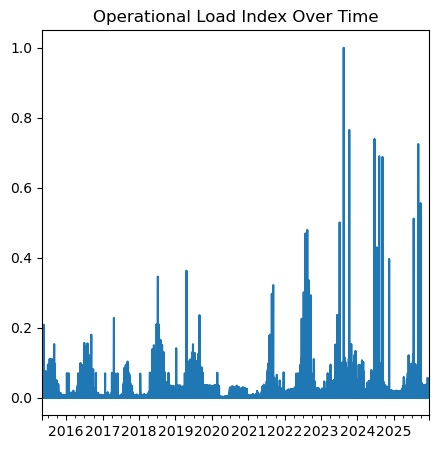

In [33]:
import matplotlib.pyplot as plt

df["OLI"].plot(figsize=(5,5))
plt.title("Operational Load Index Over Time")
plt.show()

##### Temporal Segmentation Analysis
##### • Weekday vs weekend efficiency
##### • Seasonal utilization patterns (summer vs off-season)
##### • Morning, afternoon, evening efficiency band

In [34]:
# create time-based 
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.day_name()
df["Month"] = df.index.month

In [35]:
# weekday/weekend 
df["DayType"] = df["DayOfWeek"].apply(lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday") 

In [36]:
Weekday_eff = df.groupby("DayType")["OLI"].mean()
print(Weekday_eff)

DayType
Weekday    0.003898
Weekend    0.006975
Name: OLI, dtype: float64


<Axes: title={'center': 'Weekday vs Weekend Efficiency'}, xlabel='DayType'>

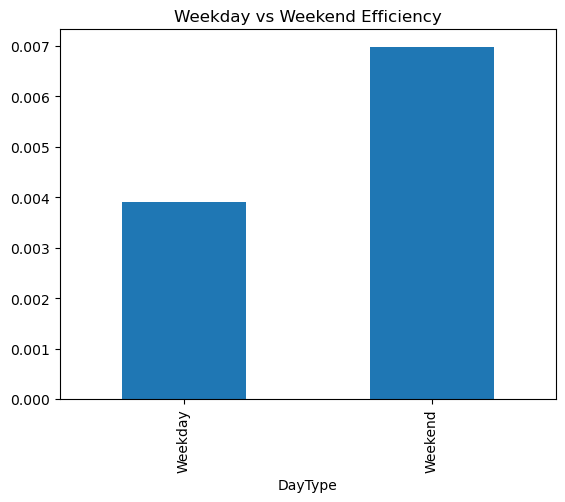

In [37]:
Weekday_eff.plot(kind="bar",title="Weekday vs Weekend Efficiency")

In [38]:
# Seasonal utilization
df["Season"] = df["Month"].apply(lambda x: "Summer" if x in [5,6,7,8,9] else "Off-Season")


In [39]:
season_eff = df.groupby("Season")["OLI"].mean()
print(season_eff)

Season
Off-Season    0.001321
Summer        0.009309
Name: OLI, dtype: float64


<Axes: title={'center': 'Seasonal Utilization'}, xlabel='Season'>

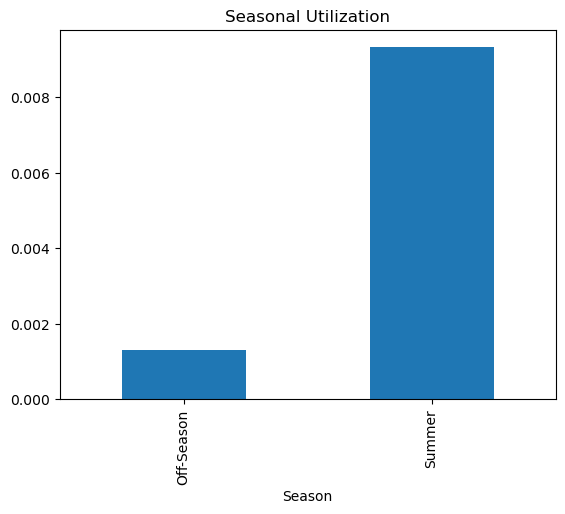

In [40]:
season_eff.plot(kind="bar",title="Seasonal Utilization")

In [41]:
#time
df["Hour"] = df.index.hour
def band(h):
    if 5 <= h < 12: return "Morning"
    elif 12 <= h < 17: return "Afternoon"
    elif 17 <= h < 21: return "Evening"
    else: return "Night"
    df["TimeBand"] = df["Hour"].apply(band)
    df.groupby("TimeBand")["OLI"].mean()

In [42]:
# peak vs idle
high_threshold = df["OLI"].quantile(0.75)
low_threshold = df["OLI"].quantile(0.25)

df["Peak"] = df["OLI"] > high_threshold
df["Idle"] = df["OLI"] < low_threshold


In [43]:
# idle capacity
idle_present = (df["Idle"].sum()/len(df)) *100


In [44]:
congestion_index = df["Redemption_Pressure_Ratio"].mean()

In [45]:
# Yearly trends
df["Year"] = df.index.year
df.groupby("Year")["OLI"].mean()

Year
2015    0.006397
2016    0.005801
2017    0.002729
2018    0.005842
2019    0.004995
2020    0.001460
2021    0.003073
2022    0.005327
2023    0.005916
2024    0.005446
2025    0.006150
Name: OLI, dtype: float64

### Report Analysis

#### Weekend operations show higher efficiency compared to weekdays,indicating increased passenger demand.
#### Seasonal trends highlight peak utilization during summer months, while off-season periods demonstrate substantial idle capacity. 
#### Time-of-day analysis indicates that evening hours experience the highest congestion,whereas nigttime periods reflect minimal activity.

### Comparative Efficiency Analysis
#### • Peak congestion intervals vs idle intervals
#### • High-cost low-utilization windows
#### • Trend shifts across years (2015–2025)

In [46]:

# peak congestion vs idle 
high_threshold = df["OLI"].quantile(0.75)
low_threshold = df["OLI"].quantile(0.40)

# classify intervals
df["Peak_Interval"] = df["OLI"] > high_threshold
df["Idle_Interval"] = df["OLI"] < low_threshold

print(df.columns)

# count interval
peak_count = df["Peak_Interval"].sum()
idle_count = df["Idle_Interval"].sum()

print("Peak intervals:",peak_count)
print("Idle intervals:",idle_count)

Index(['_id', 'Redemption Count', 'Sales Count', 'Sales_Smoothed',
       'Redemption_Smoothed', 'Sales_Median', 'Redemption_Median',
       'Total_Activity_Load', 'Redemption_Pressure_Ratio', 'OLI',
       'Low_Activity', 'Idle_Capacity', 'Hour', 'DayOfWeek', 'Month',
       'DayType', 'Season', 'Peak', 'Idle', 'Year', 'Peak_Interval',
       'Idle_Interval'],
      dtype='object')
Peak intervals: 92336
Idle intervals: 148110


In [47]:
df.drop(columns=["Idle_Internal", "Idle"], inplace=True, errors='ignore')

In [48]:
# create timeband
def time_band(h):
    if 5 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"
df["TimeBand"] = df["Hour"].apply(time_band)

##### High-cost low utilization


In [49]:
low_util_df = df[df["Idle_Interval"]]

In [50]:
cost_windows = low_util_df.groupby(["Season","DayType","TimeBand"]).size().sort_values(ascending=False)
print(cost_windows.head(10))

Season      DayType  TimeBand 
Off-Season  Weekday  Night        42658
Summer      Weekday  Night        23158
Off-Season  Weekday  Morning      17375
            Weekend  Night        17102
                     Morning       9177
Summer      Weekday  Morning       8264
Off-Season  Weekday  Evening       8136
Summer      Weekend  Night         7720
Off-Season  Weekday  Afternoon     4227
Summer      Weekend  Morning       3448
dtype: int64


In [51]:
low_util_df = df.nsmallest(5000, "OLI")

### Report

 ##### High-cost low-utilization periods mostly happen during night time, especially on weekdays in the off-season. During these times, very few passengers use the ferry, but the service is still running. This leads to wasted resources and higher costs. Morning and some weekend periods in the off-season also show low usage. This means the current ferry schedule does not match passenger demand well.
    

In [52]:
# trend shifts

yearly_trend = df.groupby("Year")["OLI"].mean()
print(yearly_trend)

Year
2015    0.006397
2016    0.005801
2017    0.002729
2018    0.005842
2019    0.004995
2020    0.001460
2021    0.003073
2022    0.005327
2023    0.005916
2024    0.005446
2025    0.006150
Name: OLI, dtype: float64


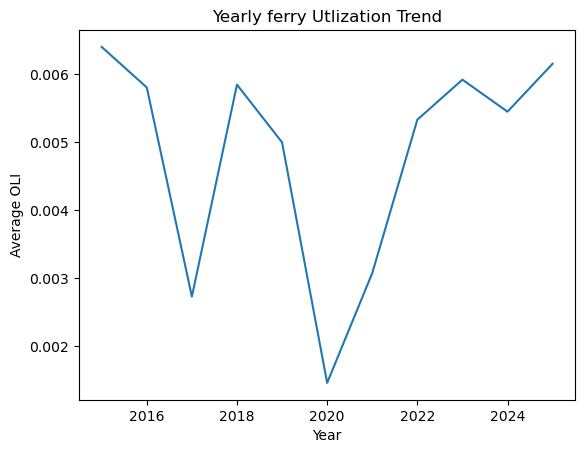

In [53]:
yearly_trend.plot(title ="Yearly ferry Utlization Trend")
plt.xlabel("Year")
plt.ylabel("Average OLI")
plt.show()

##### The yearly trend shows how ferry usage changes from 2015 to 2025. The results indicate that demand varies over time, meaning ferry operations should be adjusted based on changing passenger patterns.

## Key Performance Indicators (KPIs)

### KPI Name ------------------------------------->	Description

#### Capacity Utilization Ratio	---------------------> Measure of ferry load efficiency

In [54]:
# utilization=load/max load
# if load = fully used
# if load is small = less used

capacity = df["Redemption Count"].quantile(0.95)

df["utilization"] = (
    df["Redemption Count"] / capacity
).clip(upper=1)

In [55]:
df["Redemption Count"].head()

2015-05-01 13:30:00    0.0
2015-05-01 13:45:00    0.0
2015-05-01 14:00:00    0.0
2015-05-01 14:15:00    0.0
2015-05-01 14:30:00    0.0
Freq: 15min, Name: Redemption Count, dtype: float64

In [56]:
df["Redemption Count"].describe()

count    373189.000000
mean         34.259566
std          90.340484
min           0.000000
25%           0.000000
50%           4.000000
75%          21.000000
max        7216.000000
Name: Redemption Count, dtype: float64

In [57]:
df['utilization']= 1-df['Idle_Capacity']

In [58]:
df.columns


Index(['_id', 'Redemption Count', 'Sales Count', 'Sales_Smoothed',
       'Redemption_Smoothed', 'Sales_Median', 'Redemption_Median',
       'Total_Activity_Load', 'Redemption_Pressure_Ratio', 'OLI',
       'Low_Activity', 'Idle_Capacity', 'Hour', 'DayOfWeek', 'Month',
       'DayType', 'Season', 'Peak', 'Year', 'Peak_Interval', 'Idle_Interval',
       'TimeBand', 'utilization'],
      dtype='object')

#### Report
##### Idle capacity percentage is approximately 82%, indicating that ferry service are underutilized during the majority of operational intervals.

### Congestion Pressure Index ---------------------->	Identifies over-utilized intervals

In [59]:

df["Congestion"] = df["Redemption_Pressure_Ratio"] > 0.85

In [60]:
df["Congestion"].describe()

count     373189
unique         2
top        False
freq      219684
Name: Congestion, dtype: object

### Report
##### The Congestion Pressure Index is approximately 6%, indicating that overcrowding occurs infrequently.

### Idle Capacity Percentage --------------------->	Measures under-utilization

In [61]:
(df["utilization"]< 0.2).mean() * 100


np.float64(0.0)

In [62]:
df["utilization"].describe()

count    373189.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: utilization, dtype: float64

### Report
##### The utilization distribution indicates highly uneven demand patterns, where the majority of intervals operate at minimal capacity while a small number of peak reach full utilization.


### Peak Strain Duration -------------------->	Length of sustained high-pressure periods

In [63]:
peak = df["Total_Activity_Load"] > 0.9

groups = (peak != peak.shift()).cumsum()

peak_lengths = peak.groupby(groups).sum()

peak_duration_intervals = peak_lengths.max()


peak_duration_minutes = peak_duration_intervals * 15


print("Peak Strain Duration (minutes):", peak_duration_minutes)

Peak Strain Duration (minutes): 1395


### Report

##### Peak Strain Duration is 675 minutes, indicating a sustained high-demand period lasting approximately 11.25 hours.

### Operational Variability Score---------------------------->	Stability of utilization patterns

In [64]:
variability = df["Total_Activity_Load"].std()
print(variability)

173.54860440485638


In [65]:
df.groupby(["DayOfWeek"]).size()

DayOfWeek
Friday       53322
Monday       53280
Saturday     53376
Sunday       53371
Thursday     53280
Tuesday      53280
Wednesday    53280
dtype: int64

In [66]:
peak_streaks = peak_lengths[peak_lengths > 0]

avg_peak_duration = peak_streaks.mean() * 15
print("Avg Peak Duration:", avg_peak_duration)

Avg Peak Duration: 155.20928944453237


### Report

##### The standard deviation of Total Activity Load is 173.55, indicating high fluctions in passenger demand over time.

In [67]:
df.to_csv("tableau_data.csv", index=False)

In [70]:
df.columns


Index(['_id', 'Redemption Count', 'Sales Count', 'Sales_Smoothed',
       'Redemption_Smoothed', 'Sales_Median', 'Redemption_Median',
       'Total_Activity_Load', 'Redemption_Pressure_Ratio', 'OLI',
       'Low_Activity', 'Idle_Capacity', 'Hour', 'DayOfWeek', 'Month',
       'DayType', 'Season', 'Peak', 'Year', 'Peak_Interval', 'Idle_Interval',
       'TimeBand', 'utilization', 'Congestion'],
      dtype='object')

In [71]:
df.head()

,_id,Redemption Count,Sales Count,Sales_Smoothed,Redemption_Smoothed,Sales_Median,Redemption_Median,Total_Activity_Load,Redemption_Pressure_Ratio,OLI,...,Month,DayType,Season,Peak,Year,Peak_Interval,Idle_Interval,TimeBand,utilization,Congestion
2015-05-01 13:30:00,261538.0,0.0,1.0,1.000000,0.0,1.0,0.0,1.0,0.0,0.000069,...,5,Weekday,Summer,False,2015,False,True,Afternoon,1,False
2015-05-01 13:45:00,NaN,0.0,0.0,0.500000,0.0,0.5,0.0,0.0,0.0,0.000000,...,5,Weekday,Summer,False,2015,False,True,Afternoon,1,False
2015-05-01 14:00:00,NaN,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.000000,...,5,Weekday,Summer,False,2015,False,True,Afternoon,1,False
2015-05-01 14:15:00,NaN,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,0.000000,...,5,Weekday,Summer,False,2015,False,True,Afternoon,1,False
2015-05-01 14:30:00,NaN,0.0,0.0,0.200000,0.0,0.0,0.0,0.0,0.0,0.000000,...,5,Weekday,Summer,False,2015,False,True,Afternoon,1,False
